# ProdiRank WP1 — Tanimoto similarity + chemical-space UMAP/MDS

This notebook is a cleaned and debugged version of `Tanimoto_UMAPanalysis.py`.

It starts from the cleaned compound manifest:

```text
04_ProdiRank_Workflow/01_data_intake_cleaning/outputs/compound_manifest_clean.csv
```

It produces:

```text
04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_tanimoto_matrix.csv
04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_chemical_space_coordinates.csv
04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_reference_similarity_summary.csv
04_ProdiRank_Workflow/02_cheminformatics/outputs/figures/wp1_tanimoto_umap.png
04_ProdiRank_Workflow/02_cheminformatics/outputs/figures/wp1_tanimoto_umap.pdf
```

Main fixes:

- Removes hard-coded absolute output path.
- Defines `FIG_DIR`, which was missing in the original script.
- Uses `pathlib.Path` consistently.
- Uses the newer RDKit Morgan fingerprint generator when available.
- Falls back to MDS if `umap-learn` is not installed.
- Saves an audit table with included/excluded compounds.
- Keeps preliminary reference SMILES clearly labeled as **verify before publication**.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from sklearn.manifold import MDS

from rdkit import Chem
from rdkit.Chem import DataStructs, Descriptors, Crippen, Lipinski, rdMolDescriptors

# Prefer modern RDKit fingerprint generator API. Fall back to older API if needed.
try:
    from rdkit.Chem import rdFingerprintGenerator
    HAS_MORGAN_GENERATOR = True
except Exception:
    from rdkit.Chem import AllChem
    HAS_MORGAN_GENERATOR = False

try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False

print("RDKit import: OK")
print("Modern MorganGenerator available:", HAS_MORGAN_GENERATOR)
print("UMAP available:", UMAP_AVAILABLE)


RDKit import: OK
Modern MorganGenerator available: True
UMAP available: True


## 1. Project paths

Launch Jupyter from the project root when possible:

```bash
cd /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank
mamba activate prodirank-py
jupyter lab
```

If you launch from another directory, set `PROJECT_ROOT` manually in the next cell.


In [2]:

# Option A: auto-detect project root from current working directory.
# Option B: set PROJECT_ROOT manually if needed.

cwd = Path.cwd().resolve()

PROJECT_MARKER = "ARINBRE_Prodiginine_ProdiRank"
if PROJECT_MARKER in [p.name for p in [cwd] + list(cwd.parents)]:
    PROJECT_ROOT = next(p for p in [cwd] + list(cwd.parents) if p.name == PROJECT_MARKER)
else:
    # EDIT THIS ONLY IF AUTO-DETECTION FAILS
    PROJECT_ROOT = Path("/Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank").resolve()

INTAKE_OUT = PROJECT_ROOT / "04_ProdiRank_Workflow" / "01_data_intake_cleaning" / "outputs"
CHEM_OUT = PROJECT_ROOT / "04_ProdiRank_Workflow" / "02_cheminformatics" / "outputs"
FIG_DIR = CHEM_OUT / "figures"

MANIFEST_FILE = INTAKE_OUT / "compound_manifest_clean.csv"

CHEM_OUT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MANIFEST_FILE:", MANIFEST_FILE)
print("CHEM_OUT:", CHEM_OUT)
print("FIG_DIR:", FIG_DIR)
print("Manifest exists:", MANIFEST_FILE.exists())


PROJECT_ROOT: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank
MANIFEST_FILE: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/01_data_intake_cleaning/outputs/compound_manifest_clean.csv
CHEM_OUT: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs
FIG_DIR: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/figures
Manifest exists: True


## 2. Reference compounds

These reference SMILES are included to anchor Brian's compound series against natural prodigiosin and the clinical comparator obatoclax/GX15-070.

**Important:** keep these marked as `verify_before_publication = True` until manually cross-checked against PubChem/ChEMBL or Brian/Robert-approved references.


In [3]:

REFERENCES = [
    {
        "compound_id": "Prodigiosin (natural)",
        "smiles_clean": "COC1=C(/C=C2NC(=C\\C=C3/NC=CC=C3)C=C2)NC1",
        "category": "Reference · natural",
        "notes": "PubChem CID 5351172 — verify before publication",
        "verify_before_publication": True,
    },
    {
        "compound_id": "Obatoclax (GX15-070)",
        "smiles_clean": "COc1ccc(cc1)/C=C1\\NC(=C\\c2cc[nH]c2)C=C1",
        "category": "Reference · clinical",
        "notes": "ChEMBL CHEMBL452504 / PubChem CID 44477473 — verify before publication",
        "verify_before_publication": True,
    },
]
ref_df = pd.DataFrame(REFERENCES)
ref_df


,compound_id,smiles_clean,category,notes,verify_before_publication
0,Prodigiosin (natural),COC1=C(/C=C2NC(=C\C=C3/NC=CC=C3)C=C2)NC1,Reference · natural,PubChem CID 5351172 — verify before publication,True
1,Obatoclax (GX15-070),COc1ccc(cc1)/C=C1\NC(=C\c2cc[nH]c2)C=C1,Reference · clinical,ChEMBL CHEMBL452504 / PubChem CID 44477473 — v...,True


## 3. Load and prepare compound manifest

In [4]:

manifest = pd.read_csv(MANIFEST_FILE)

# Normalize Boolean column if it arrived as string from CSV.
manifest["smiles_valid"] = manifest["smiles_valid"].astype(str).str.lower().isin(["true", "1", "yes"])

valid_manifest = manifest.loc[manifest["smiles_valid"]].copy()

if valid_manifest.empty:
    raise ValueError("No valid SMILES found in compound_manifest_clean.csv. Check the cleaning notebook and RDKit environment.")

def assign_category(cid: str) -> str:
    cid = str(cid)
    if cid.startswith("JP-Cmpd"):
        return "Grant target (proposed)"
    if cid.startswith("BW-II"):
        return "Made / characterized"
    if cid.startswith("Proposed"):
        return "Proposed analogue"
    return "Other"

valid_manifest["category"] = valid_manifest["compound_id"].apply(assign_category)
valid_manifest["verify_before_publication"] = valid_manifest.get("needs_manual_review", False)
valid_manifest["notes"] = valid_manifest.get("notes_raw", "")

all_cpds = pd.concat(
    [
        valid_manifest[["compound_id", "smiles_clean", "category", "verify_before_publication", "notes"]],
        ref_df[["compound_id", "smiles_clean", "category", "verify_before_publication", "notes"]],
    ],
    ignore_index=True,
)

def short_label(cid: str) -> str:
    return (
        str(cid)
        .replace("Proposed-benzothiazole-", "Prop-")
        .replace("Prodigiosin (natural)", "Prodigiosin")
        .replace("Obatoclax (GX15-070)", "Obatoclax")
    )

all_cpds["label"] = all_cpds["compound_id"].apply(short_label)

print("Manifest rows:", manifest.shape[0])
print("Valid manifest rows:", valid_manifest.shape[0])
print("Total with references:", all_cpds.shape[0])
all_cpds


Manifest rows: 13
Valid manifest rows: 13
Total with references: 15


,compound_id,smiles_clean,category,verify_before_publication,notes,label
0,BW-II-1,COC1=CC(c2ccc[nH]2)=N/C1=C\c1[nH]c(-c2ccc[nH]2...,Made / characterized,False,confirmed by MS,BW-II-1
1,BW-II-103,c1c[nH]c(-c2nc3ccccc3s2)c1,Made / characterized,False,1HNMR,BW-II-103
2,BW-II-106,Clc1ccc2sc(-c3ccc[nH]3)nc2c1,Made / characterized,False,NaN,BW-II-106
3,BW-II-110,COc1ccc2nc(-c3ccc[nH]3)sc2c1,Made / characterized,False,NaN,BW-II-110
4,Proposed-benzothiazole-001,COc1cc(-c2ccc[nH]2)[nH]c1-c1nc2ccccc2s1,Proposed analogue,True,NaN,Prop-001
5,JP-Cmpd-6,COC1=CC(c2nc3ccccc3s2)=N/C1=C\c1ccc[nH]1,Grant target (proposed),False,NaN,JP-Cmpd-6
6,JP-Cmpd-10,COC1=CC(c2ccc[nH]2)=N/C1=C\c1nc2ccccc2s1,Grant target (proposed),False,NaN,JP-Cmpd-10
7,Proposed-benzothiazole-002,CCCc1ccc2nc(-c3[nH]c(-c4ccc[nH]4)cc3OC)sc2c1,Proposed analogue,True,NaN,Prop-002
8,Proposed-benzothiazole-003,COc1cc(-c2ccc[nH]2)[nH]c1-c1nc2c(C)ccc(C)c2s1,Proposed analogue,True,NaN,Prop-003
9,Proposed-benzothiazole-004,COc1ccc2nc(-c3[nH]c(-c4ccc[nH]4)cc3OC)sc2c1,Proposed analogue,True,NaN,Prop-004


## 4. Validate SMILES and compute descriptors

In [5]:

def mol_from_smiles(s):
    if pd.isna(s) or str(s).strip() == "":
        return None
    return Chem.MolFromSmiles(str(s).strip())

all_cpds["mol"] = all_cpds["smiles_clean"].apply(mol_from_smiles)
all_cpds["rdkit_valid"] = all_cpds["mol"].notna()

excluded = all_cpds.loc[~all_cpds["rdkit_valid"], ["compound_id", "smiles_clean", "category", "notes"]].copy()
cpds = all_cpds.loc[all_cpds["rdkit_valid"]].copy().reset_index(drop=True)

if cpds.shape[0] < 3:
    raise ValueError("Too few valid molecules for chemical-space embedding.")

# Basic descriptors for audit/reporting
cpds["mw"] = cpds["mol"].apply(Descriptors.MolWt)
cpds["logp"] = cpds["mol"].apply(Crippen.MolLogP)
cpds["tpsa"] = cpds["mol"].apply(rdMolDescriptors.CalcTPSA)
cpds["hbd"] = cpds["mol"].apply(Lipinski.NumHDonors)
cpds["hba"] = cpds["mol"].apply(Lipinski.NumHAcceptors)
cpds["rotatable_bonds"] = cpds["mol"].apply(Lipinski.NumRotatableBonds)
cpds["aromatic_rings"] = cpds["mol"].apply(rdMolDescriptors.CalcNumAromaticRings)
cpds["heavy_atoms"] = cpds["mol"].apply(lambda m: m.GetNumHeavyAtoms())

print(f"Valid RDKit molecules: {cpds.shape[0]} / {all_cpds.shape[0]}")
if not excluded.empty:
    print("Excluded compounds:")
    display(excluded)

cpds[["compound_id", "category", "mw", "logp", "tpsa", "hbd", "hba", "rotatable_bonds", "aromatic_rings", "verify_before_publication"]]


Valid RDKit molecules: 15 / 15


,compound_id,category,mw,logp,tpsa,hbd,hba,rotatable_bonds,aromatic_rings,verify_before_publication
0,BW-II-1,Made / characterized,334.379,3.72060,78.19,3,3,5,3,False
1,BW-II-103,Made / characterized,200.266,3.29140,28.68,1,2,1,3,False
2,BW-II-106,Made / characterized,234.711,3.94480,28.68,1,2,1,3,False
3,BW-II-110,Made / characterized,230.292,3.30000,37.91,1,3,2,3,False
4,Proposed-benzothiazole-001,Proposed analogue,295.367,4.29510,53.70,2,3,3,4,True
5,JP-Cmpd-6,Grant target (proposed),307.378,3.99850,50.27,1,4,3,3,False
6,JP-Cmpd-10,Grant target (proposed),307.378,3.99850,50.27,1,4,3,3,False
7,Proposed-benzothiazole-002,Proposed analogue,337.448,5.24760,53.70,2,3,5,4,True
8,Proposed-benzothiazole-003,Proposed analogue,323.421,4.91194,53.70,2,3,3,4,True
9,Proposed-benzothiazole-004,Proposed analogue,325.393,4.30370,62.93,2,4,4,4,True


## 5. Morgan fingerprints and pairwise Tanimoto matrix

Fingerprint used: Morgan/ECFP4-like fingerprint, radius 2, 2048 bits.


In [6]:

RADIUS = 2
NBITS = 2048

if HAS_MORGAN_GENERATOR:
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=RADIUS, fpSize=NBITS)
    def morgan_fp(mol):
        return generator.GetFingerprint(mol)
else:
    def morgan_fp(mol):
        return AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=NBITS)

fps = [morgan_fp(m) for m in cpds["mol"]]
n = len(fps)

sim = np.zeros((n, n), dtype=float)
for i in range(n):
    sim[i, :] = DataStructs.BulkTanimotoSimilarity(fps[i], fps)

sim_df = pd.DataFrame(sim, index=cpds["compound_id"], columns=cpds["compound_id"])
sim_out = CHEM_OUT / "wp1_tanimoto_matrix.csv"
sim_df.to_csv(sim_out)

print("Tanimoto matrix saved:", sim_out)
sim_df.round(3)


Tanimoto matrix saved: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_tanimoto_matrix.csv


compound_id,BW-II-1,BW-II-103,BW-II-106,BW-II-110,Proposed-benzothiazole-001,JP-Cmpd-6,JP-Cmpd-10,Proposed-benzothiazole-002,Proposed-benzothiazole-003,Proposed-benzothiazole-004,Proposed-benzothiazole-005,Proposed-benzothiazole-006,Proposed-benzothiazole-007,Prodigiosin (natural),Obatoclax (GX15-070)
compound_id,,,,,,,,,,,,,,,
BW-II-1,1.000,0.228,0.233,0.300,0.400,0.419,0.544,0.353,0.393,0.381,0.375,0.358,0.379,0.155,0.197
BW-II-103,0.228,1.000,0.667,0.600,0.591,0.451,0.451,0.393,0.315,0.431,0.370,0.351,0.400,0.062,0.093
BW-II-106,0.233,0.667,1.000,0.545,0.451,0.322,0.322,0.367,0.316,0.400,0.393,0.328,0.373,0.059,0.086
BW-II-110,0.300,0.600,0.545,1.000,0.529,0.390,0.390,0.509,0.386,0.723,0.414,0.393,0.518,0.118,0.218
Proposed-benzothiazole-001,0.400,0.591,0.451,0.529,1.000,0.467,0.467,0.704,0.635,0.776,0.692,0.655,0.717,0.123,0.159
JP-Cmpd-6,0.419,0.451,0.322,0.390,0.467,1.000,0.643,0.333,0.271,0.358,0.314,0.301,0.357,0.132,0.167
JP-Cmpd-10,0.544,0.451,0.322,0.390,0.467,0.643,1.000,0.333,0.309,0.358,0.333,0.319,0.357,0.132,0.167
Proposed-benzothiazole-002,0.353,0.393,0.367,0.509,0.704,0.333,0.333,1.000,0.550,0.727,0.574,0.547,0.678,0.125,0.141
Proposed-benzothiazole-003,0.393,0.315,0.316,0.386,0.635,0.271,0.309,0.550,1.000,0.600,0.648,0.614,0.559,0.122,0.156


## 6. Chemical-space embedding

The notebook uses UMAP if available. If not, it uses metric MDS on the Tanimoto distance matrix. Both are acceptable for exploratory chemical-space visualization with a small compound set.


In [7]:

dist = 1 - sim
np.fill_diagonal(dist, 0.0)

if UMAP_AVAILABLE:
    reducer = umap.UMAP(
        n_components=2,
        metric="precomputed",
        n_neighbors=max(2, min(5, n - 1)),
        min_dist=0.35,
        spread=1.0,
        random_state=42,
        n_jobs=1,
    )
    embed = reducer.fit_transform(dist)
    method = "UMAP"
else:
    reducer = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=42,
        n_init=10,
        normalized_stress="auto",
    )
    embed = reducer.fit_transform(dist)
    method = "MDS"

coord_df = cpds[["compound_id", "label", "category", "verify_before_publication", "mw", "logp", "tpsa"]].copy()
coord_df[f"{method}_1"] = embed[:, 0]
coord_df[f"{method}_2"] = embed[:, 1]
coord_out = CHEM_OUT / "wp1_chemical_space_coordinates.csv"
coord_df.to_csv(coord_out, index=False)

print(f"Embedding method: {method}")
print("Coordinates saved:", coord_out)
coord_df


Embedding method: UMAP
Coordinates saved: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_chemical_space_coordinates.csv


,compound_id,label,category,verify_before_publication,mw,logp,tpsa,UMAP_1,UMAP_2
0,BW-II-1,BW-II-1,Made / characterized,False,334.379,3.72060,78.19,7.256673,16.139374
1,BW-II-103,BW-II-103,Made / characterized,False,200.266,3.29140,28.68,8.361273,15.885588
2,BW-II-106,BW-II-106,Made / characterized,False,234.711,3.94480,28.68,8.505664,15.085615
3,BW-II-110,BW-II-110,Made / characterized,False,230.292,3.30000,37.91,9.067098,14.951825
4,Proposed-benzothiazole-001,Prop-001,Proposed analogue,True,295.367,4.29510,53.70,9.503520,16.278738
5,JP-Cmpd-6,JP-Cmpd-6,Grant target (proposed),False,307.378,3.99850,50.27,6.249396,15.961943
6,JP-Cmpd-10,JP-Cmpd-10,Grant target (proposed),False,307.378,3.99850,50.27,6.702791,16.630806
7,Proposed-benzothiazole-002,Prop-002,Proposed analogue,True,337.448,5.24760,53.70,10.604008,14.865640
8,Proposed-benzothiazole-003,Prop-003,Proposed analogue,True,323.421,4.91194,53.70,9.877741,17.476738
9,Proposed-benzothiazole-004,Prop-004,Proposed analogue,True,325.393,4.30370,62.93,9.885537,15.317001


## 7. Plot chemical space and similarity heatmap

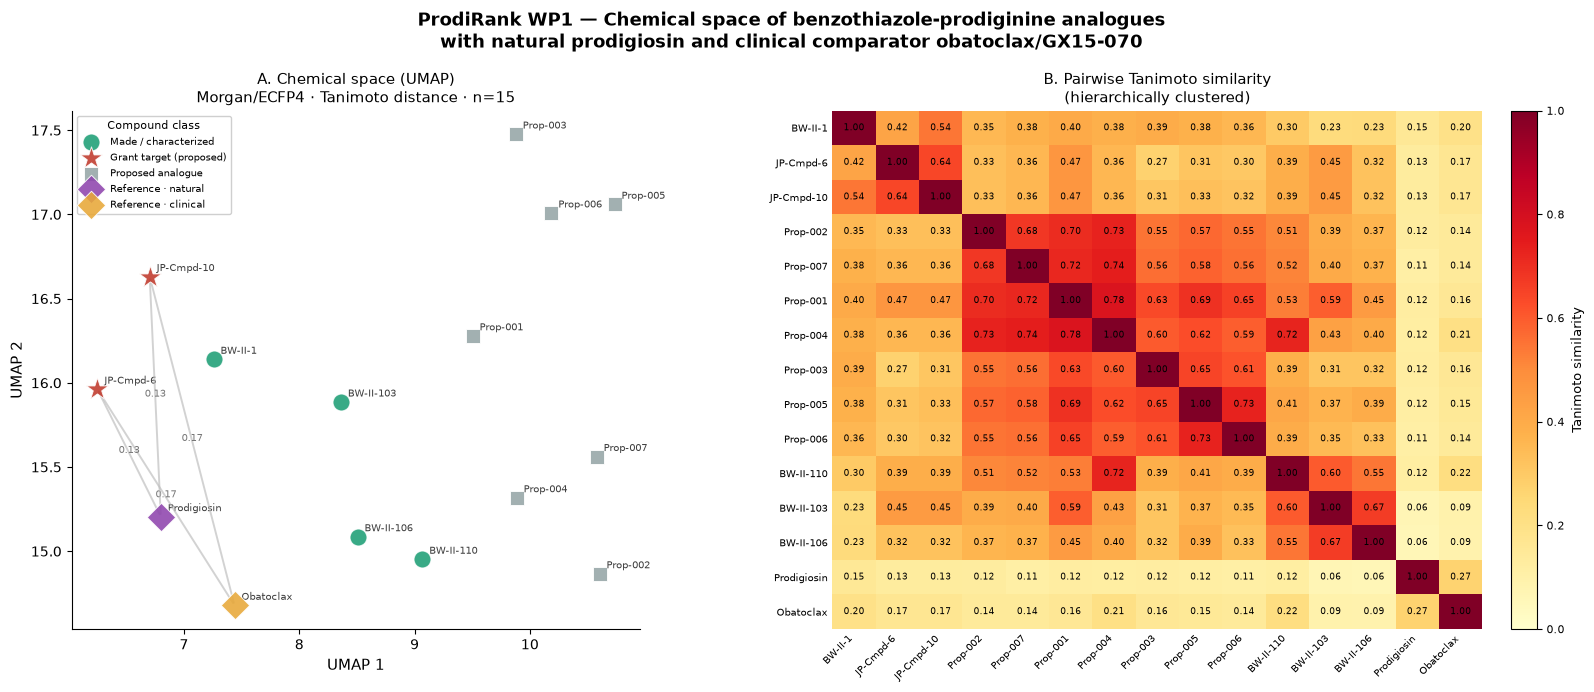

Figure saved: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/figures/wp1_tanimoto_umap.png
Figure saved: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/figures/wp1_tanimoto_umap.pdf


In [8]:

STYLE = {
    "Made / characterized":    dict(color="#1D9E75", s=150, marker="o", zorder=3),
    "Grant target (proposed)": dict(color="#C0392B", s=280, marker="*", zorder=5),
    "Proposed analogue":       dict(color="#95A5A6", s=90,  marker="s", zorder=2),
    "Reference · natural":     dict(color="#8E44AD", s=210, marker="D", zorder=4),
    "Reference · clinical":    dict(color="#E8A838", s=210, marker="D", zorder=4),
    "Other":                   dict(color="#777777", s=100, marker="o", zorder=1),
}

fig = plt.figure(figsize=(16, 7.2))
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1, 1.25],
    left=0.05, right=0.97,
    top=0.84, bottom=0.12,
    wspace=0.30,
)

# Panel A: chemical space
ax1 = fig.add_subplot(gs[0])

for cat, style in STYLE.items():
    mask = cpds["category"] == cat
    if not mask.any():
        continue
    ax1.scatter(
        embed[mask, 0], embed[mask, 1],
        label=cat,
        alpha=0.88,
        edgecolors="white",
        linewidths=0.7,
        **style,
    )

for i, row in cpds.iterrows():
    ax1.annotate(
        row["label"],
        (embed[i, 0], embed[i, 1]),
        fontsize=7,
        xytext=(5, 4),
        textcoords="offset points",
        color="#333333",
        alpha=0.95,
    )

# Draw connections from references to key grant targets.
for ref in ["Obatoclax (GX15-070)", "Prodigiosin (natural)"]:
    if ref not in set(cpds["compound_id"]):
        continue
    ri = cpds.index[cpds["compound_id"] == ref][0]
    for target in ["JP-Cmpd-6", "JP-Cmpd-10"]:
        if target not in set(cpds["compound_id"]):
            continue
        ti = cpds.index[cpds["compound_id"] == target][0]
        sim_val = sim[ri, ti]
        ax1.annotate(
            "",
            xy=(embed[ti, 0], embed[ti, 1]),
            xytext=(embed[ri, 0], embed[ri, 1]),
            arrowprops=dict(arrowstyle="-", color="#BBBBBB", lw=1.4, alpha=0.65),
        )
        mx = (embed[ri, 0] + embed[ti, 0]) / 2
        my = (embed[ri, 1] + embed[ti, 1]) / 2
        ax1.text(mx, my, f"{sim_val:.2f}", fontsize=7, color="#777777", ha="center")

ax1.set_xlabel(f"{method} 1", fontsize=11)
ax1.set_ylabel(f"{method} 2", fontsize=11)
ax1.set_title(f"A. Chemical space ({method})\nMorgan/ECFP4 · Tanimoto distance · n={n}", fontsize=11)
ax1.spines[["top", "right"]].set_visible(False)
ax1.legend(frameon=True, framealpha=0.93, fontsize=7.5, loc="best", title="Compound class", title_fontsize=8)

# Panel B: clustered heatmap
ax2 = fig.add_subplot(gs[1])

# Convert distance matrix to condensed vector for clustering.
dist_cond = squareform(dist, checks=False)
link = linkage(dist_cond, method="average")
order = leaves_list(link)

sim_ordered = sim[np.ix_(order, order)]
labels_ordered = [cpds.iloc[i]["label"] for i in order]

im = ax2.imshow(sim_ordered, vmin=0, vmax=1, aspect="auto", cmap="YlOrRd")

ax2.set_xticks(np.arange(n))
ax2.set_yticks(np.arange(n))
ax2.set_xticklabels(labels_ordered, rotation=45, ha="right", fontsize=7)
ax2.set_yticklabels(labels_ordered, fontsize=7)

for i in range(n):
    for j in range(n):
        ax2.text(j, i, f"{sim_ordered[i, j]:.2f}", ha="center", va="center", fontsize=6.4, color="black")

ax2.set_title("B. Pairwise Tanimoto similarity\n(hierarchically clustered)", fontsize=11)
ax2.tick_params(length=0)
for spine in ax2.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("Tanimoto similarity", fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    "ProdiRank WP1 — Chemical space of benzothiazole-prodiginine analogues\n"
    "with natural prodigiosin and clinical comparator obatoclax/GX15-070",
    fontsize=13,
    y=0.98,
    fontweight="bold",
)

png_out = FIG_DIR / "wp1_tanimoto_umap.png"
pdf_out = FIG_DIR / "wp1_tanimoto_umap.pdf"
plt.savefig(png_out, dpi=300, bbox_inches="tight")
plt.savefig(pdf_out, bbox_inches="tight")
plt.show()

print("Figure saved:", png_out)
print("Figure saved:", pdf_out)


## 8. Grant-relevant similarity summary

In [9]:

rows = []
key_targets = ["JP-Cmpd-6", "JP-Cmpd-10"]
refs = ["Obatoclax (GX15-070)", "Prodigiosin (natural)"]

for target in key_targets:
    if target not in sim_df.index:
        continue
    for ref in refs:
        if ref not in sim_df.columns:
            continue
        rows.append({
            "target_compound": target,
            "reference_compound": ref,
            "tanimoto_similarity": sim_df.loc[target, ref],
        })

# Top neighbors for every compound
for cid in sim_df.index:
    neighbors = sim_df.loc[cid].drop(cid, errors="ignore").sort_values(ascending=False)
    for rank, (neighbor, val) in enumerate(neighbors.head(5).items(), start=1):
        rows.append({
            "target_compound": cid,
            "reference_compound": neighbor,
            "neighbor_rank": rank,
            "tanimoto_similarity": val,
        })

summary_df = pd.DataFrame(rows)
summary_out = CHEM_OUT / "wp1_reference_similarity_summary.csv"
summary_df.to_csv(summary_out, index=False)

print("Similarity summary saved:", summary_out)
print("\nKey targets vs reference compounds:")
display(summary_df.loc[summary_df["target_compound"].isin(key_targets) & summary_df["reference_compound"].isin(refs)].copy())

print("\nTop neighbors for JP-Cmpd-6 and JP-Cmpd-10:")
for target in key_targets:
    if target in sim_df.index:
        print(f"\n{target}")
        print(sim_df.loc[target].drop(target, errors="ignore").sort_values(ascending=False).head(8).round(3).to_string())


Similarity summary saved: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_reference_similarity_summary.csv

Key targets vs reference compounds:


,target_compound,reference_compound,tanimoto_similarity,neighbor_rank
0,JP-Cmpd-6,Obatoclax (GX15-070),0.166667,NaN
1,JP-Cmpd-6,Prodigiosin (natural),0.131579,NaN
2,JP-Cmpd-10,Obatoclax (GX15-070),0.166667,NaN
3,JP-Cmpd-10,Prodigiosin (natural),0.131579,NaN



Top neighbors for JP-Cmpd-6 and JP-Cmpd-10:

JP-Cmpd-6
compound_id
JP-Cmpd-10                    0.643
Proposed-benzothiazole-001    0.467
BW-II-103                     0.451
BW-II-1                       0.419
BW-II-110                     0.390
Proposed-benzothiazole-004    0.358
Proposed-benzothiazole-007    0.357
Proposed-benzothiazole-002    0.333

JP-Cmpd-10
compound_id
JP-Cmpd-6                     0.643
BW-II-1                       0.544
Proposed-benzothiazole-001    0.467
BW-II-103                     0.451
BW-II-110                     0.390
Proposed-benzothiazole-004    0.358
Proposed-benzothiazole-007    0.357
Proposed-benzothiazole-002    0.333


## 9. Basic liability flag overlay

This is an early descriptor-level screen only. It is **not** an ADMET/toxicity prediction. It helps decide which compounds deserve closer review before docking and experimental prioritization.


In [10]:

def basic_descriptor_flags(row):
    flags = []
    if row["mw"] > 500:
        flags.append("MW_GT_500")
    if row["logp"] > 5:
        flags.append("LOGP_GT_5")
    if row["hbd"] > 5:
        flags.append("HBD_GT_5")
    if row["hba"] > 10:
        flags.append("HBA_GT_10")
    if row["tpsa"] > 140:
        flags.append("TPSA_GT_140")
    if row["rotatable_bonds"] > 10:
        flags.append("ROT_BONDS_GT_10")
    return ";".join(flags) if flags else "PASS_BASIC_FILTERS"

def descriptor_liability_class(row):
    if row["logp"] > 5:
        return "EARLY_LIPOPHILICITY_FLAG"
    if row["logp"] >= 4.5:
        return "MODERATE_LIPOPHILICITY_WATCH"
    if row["tpsa"] >= 70:
        return "POLARITY_SHIFT_WATCH"
    return "LOW_BASIC_DESCRIPTOR_CONCERN"

liability_df = cpds.drop(columns=["mol"]).copy()
liability_df["basic_descriptor_flags"] = liability_df.apply(basic_descriptor_flags, axis=1)
liability_df["descriptor_liability_class"] = liability_df.apply(descriptor_liability_class, axis=1)

liability_out = CHEM_OUT / "wp1_descriptor_liability_flags_with_references.csv"
liability_df.to_csv(liability_out, index=False)

print("Descriptor liability table saved:", liability_out)
liability_df[["compound_id", "category", "mw", "logp", "tpsa", "basic_descriptor_flags", "descriptor_liability_class", "verify_before_publication"]]


Descriptor liability table saved: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_descriptor_liability_flags_with_references.csv


,compound_id,category,mw,logp,tpsa,basic_descriptor_flags,descriptor_liability_class,verify_before_publication
0,BW-II-1,Made / characterized,334.379,3.72060,78.19,PASS_BASIC_FILTERS,POLARITY_SHIFT_WATCH,False
1,BW-II-103,Made / characterized,200.266,3.29140,28.68,PASS_BASIC_FILTERS,LOW_BASIC_DESCRIPTOR_CONCERN,False
2,BW-II-106,Made / characterized,234.711,3.94480,28.68,PASS_BASIC_FILTERS,LOW_BASIC_DESCRIPTOR_CONCERN,False
3,BW-II-110,Made / characterized,230.292,3.30000,37.91,PASS_BASIC_FILTERS,LOW_BASIC_DESCRIPTOR_CONCERN,False
4,Proposed-benzothiazole-001,Proposed analogue,295.367,4.29510,53.70,PASS_BASIC_FILTERS,LOW_BASIC_DESCRIPTOR_CONCERN,True
5,JP-Cmpd-6,Grant target (proposed),307.378,3.99850,50.27,PASS_BASIC_FILTERS,LOW_BASIC_DESCRIPTOR_CONCERN,False
6,JP-Cmpd-10,Grant target (proposed),307.378,3.99850,50.27,PASS_BASIC_FILTERS,LOW_BASIC_DESCRIPTOR_CONCERN,False
7,Proposed-benzothiazole-002,Proposed analogue,337.448,5.24760,53.70,LOGP_GT_5,EARLY_LIPOPHILICITY_FLAG,True
8,Proposed-benzothiazole-003,Proposed analogue,323.421,4.91194,53.70,PASS_BASIC_FILTERS,MODERATE_LIPOPHILICITY_WATCH,True
9,Proposed-benzothiazole-004,Proposed analogue,325.393,4.30370,62.93,PASS_BASIC_FILTERS,LOW_BASIC_DESCRIPTOR_CONCERN,True


## 10. Audit notes and next steps

In [11]:

audit_lines = []
audit_lines.append("# ProdiRank WP1 Tanimoto/chemical-space audit\n")
audit_lines.append(f"- Input manifest: `{MANIFEST_FILE}`")
audit_lines.append(f"- Valid cleaned manifest compounds: {valid_manifest.shape[0]}")
audit_lines.append(f"- Reference compounds added: {len(REFERENCES)}")
audit_lines.append(f"- Total valid RDKit molecules analyzed: {cpds.shape[0]}")
audit_lines.append(f"- Fingerprint: Morgan/ECFP4-like, radius={RADIUS}, bits={NBITS}")
audit_lines.append(f"- Embedding method: {method}")
audit_lines.append(f"- Matrix output: `{sim_out}`")
audit_lines.append(f"- Coordinate output: `{coord_out}`")
audit_lines.append(f"- Figure output: `{png_out}` and `{pdf_out}`")
audit_lines.append("\n## Guardrails")
audit_lines.append("- Reference SMILES for prodigiosin and obatoclax must be manually verified before publication/grant submission.")
audit_lines.append("- Tanimoto similarity is a structural-similarity metric, not a biological activity claim.")
audit_lines.append("- UMAP/MDS position is exploratory and should not be overinterpreted.")
audit_lines.append("- Proposed analogues marked for manual review require Brian confirmation before being treated as final chemistry.")
audit_lines.append("\n## Next steps")
audit_lines.append("- Add Brian-confirmed compound mapping once received.")
audit_lines.append("- Add verified prodigiosin/obatoclax reference SMILES from PubChem/ChEMBL.")
audit_lines.append("- Expand library with literature prodiginine analogues.")
audit_lines.append("- Add ADMET/off-target prediction outputs in the OffTarget_Guard module.")

audit_out = CHEM_OUT / "wp1_tanimoto_umap_audit.md"
audit_out.write_text("\n".join(audit_lines))
print("Audit written:", audit_out)
print("\n".join(audit_lines))


Audit written: /Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_tanimoto_umap_audit.md
# ProdiRank WP1 Tanimoto/chemical-space audit

- Input manifest: `/Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/01_data_intake_cleaning/outputs/compound_manifest_clean.csv`
- Valid cleaned manifest compounds: 13
- Reference compounds added: 2
- Total valid RDKit molecules analyzed: 15
- Fingerprint: Morgan/ECFP4-like, radius=2, bits=2048
- Embedding method: UMAP
- Matrix output: `/Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_tanimoto_matrix.csv`
- Coordinate output: `/Users/dhusiakalyani/Desktop/PROJECTS/ARPILOT/BrianWalker/ARINBRE_Prodiginine_ProdiRank/04_ProdiRank_Workflow/02_cheminformatics/outputs/wp1_chemical_space_coordinates.csv`
- Figure output: 

## One-sentence interpretation

Preliminary WP1 analysis places Brian’s benzothiazole-prodiginine analogues into a comparator-anchored chemical space against natural prodigiosin and clinical-reference obatoclax, generating a Tanimoto similarity matrix and early descriptor/liability flags for downstream ProdiRank prioritization.
